# Titanic Dataset — Data Cleaning & Preprocessing

### Objective
Clean and preprocess the given Titanic dataset so that it is ready for machine learning.

The work follows the data-cleaning and preprocessing ideas from the provided ML Prep session: first inspect the data, identify missing values and duplicates, check suspicious values/outliers, perform feature engineering, encode categorical variables, and scale numerical features where required.

**Important:** The original dataset is kept unchanged. All cleaning is performed through code so the complete process is visible and reproducible.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

print("Libraries imported successfully")


Libraries imported successfully


## 1. Load the Original Dataset

The raw CSV file is loaded directly. No preprocessed Excel/CSV file is used.

This is important because the notebook itself shows exactly what was present in the original dataset before cleaning.


In [2]:
df_raw = pd.read_csv("titanic uncleaned.csv")

print("Original shape:", df_raw.shape)
df_raw.head(10)


Original shape: (418, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,0,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,0,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


### Initial observations

The dataset contains passenger information such as passenger class, name, sex, age, family information, ticket, fare, cabin, and embarkation point. `Survived` is the target column.

Next, the structure and data types are checked before making any cleaning decisions.


In [3]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [4]:
df_raw.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


## 2. Check Data Quality

The first checks are:

- Missing values
- Duplicate rows
- Unique values in categorical columns
- Basic ranges of numerical columns

These checks help decide what preprocessing is actually needed instead of applying cleaning steps blindly.


In [5]:
missing = df_raw.isnull().sum()
missing_percent = (df_raw.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": missing_percent
})

missing_summary


,Missing Values,Missing %
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
Age,86,20.57
SibSp,0,0.00
Parch,0,0.00
Ticket,0,0.00
Fare,1,0.24


In [6]:
print("Duplicate rows:", df_raw.duplicated().sum())

print("\nUnique values:")
for col in ["Survived", "Pclass", "Sex", "Embarked"]:
    print(f"{col}: {df_raw[col].unique()}")


Duplicate rows: 0

Unique values:
Survived: [0 1]
Pclass: [3 2 1]
Sex: ['male' 'female']
Embarked: ['Q' 'S' 'C']


### Missing-value findings

`Age` contains missing values and `Fare` has one missing value. `Cabin` has a very high proportion of missing values.

Following the approach from the preparation material, numerical missing values can be handled using imputation, while a column with a very large amount of missing information can be considered for removal.

`Cabin` is therefore removed because most of its values are missing. `Age` and `Fare` will be median-imputed during preprocessing.


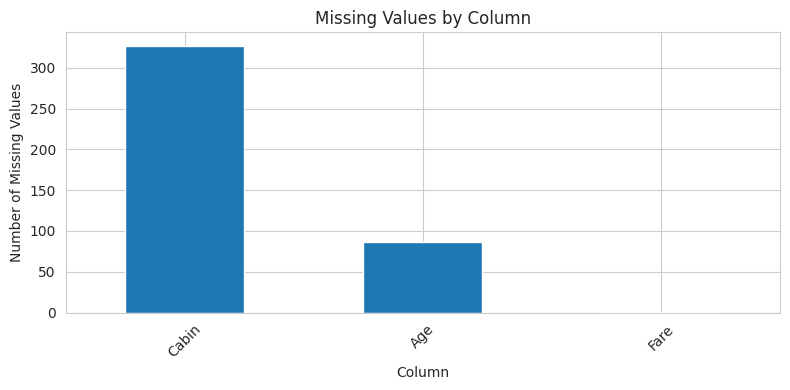

In [7]:
plt.figure(figsize=(8, 4))
missing[missing > 0].sort_values(ascending=False).plot(kind="bar")
plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 3. Check Numerical Distributions and Possible Outliers

The preparation material recommends using summary statistics and the IQR rule to identify possible outliers.

For Titanic, unusually high `Fare` values can represent genuine passengers who paid expensive fares, so they should not automatically be deleted. We will inspect them first and retain meaningful observations.


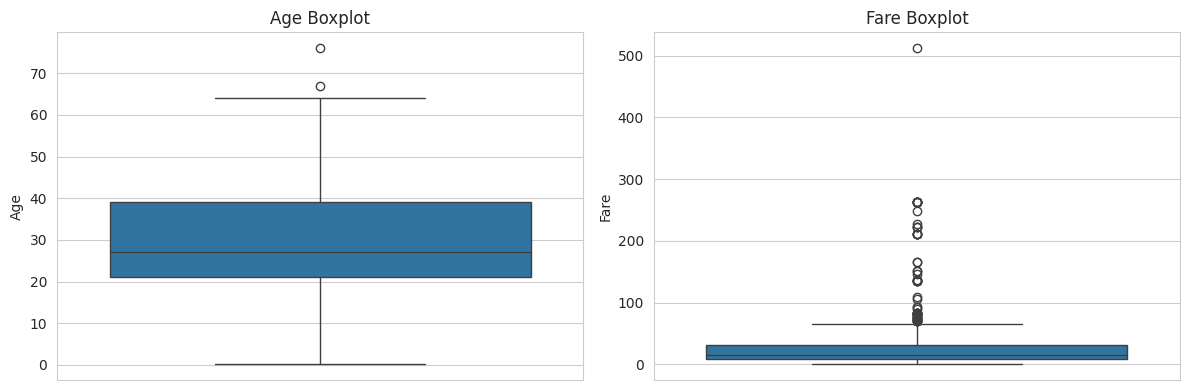

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=df_raw["Age"], ax=axes[0])
axes[0].set_title("Age Boxplot")

sns.boxplot(y=df_raw["Fare"], ax=axes[1])
axes[1].set_title("Fare Boxplot")

plt.tight_layout()
plt.show()


In [9]:
def iqr_outlier_count(series):
    series = series.dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return lower, upper, mask.sum()

for col in ["Age", "Fare", "SibSp", "Parch"]:
    lower, upper, count = iqr_outlier_count(df_raw[col])
    print(f"{col}: valid IQR range = {lower:.2f} to {upper:.2f}, possible outliers = {count}")


Age: valid IQR range = -6.00 to 66.00, possible outliers = 2
Fare: valid IQR range = -27.51 to 66.91, possible outliers = 55
SibSp: valid IQR range = -1.50 to 2.50, possible outliers = 11
Parch: valid IQR range = 0.00 to 0.00, possible outliers = 94


### Outlier decision

The IQR check identifies unusually large values, especially in `Fare`. However, these are not automatically data errors. A high fare can be a real observation in the Titanic dataset.

Therefore, no rows are deleted only because they are statistical outliers. This avoids losing potentially useful information.


## 4. Create a Clean Working Dataset

The raw dataset is preserved as `df_raw`.

For the working dataset:

1. Remove exact duplicate rows if any exist.
2. Remove `Cabin` because of excessive missing values.
3. Create `FamilySize` from `SibSp` and `Parch`.
4. Create `IsAlone` from `FamilySize`.
5. Remove high-cardinality/non-useful identifier fields for this ML exercise: `PassengerId`, `Name`, and `Ticket`.

The target `Survived` is kept separately.


In [10]:
df = df_raw.copy()

# Remove exact duplicate rows
before = len(df)
df = df.drop_duplicates().copy()
duplicates_removed = before - len(df)

# Drop Cabin because most values are missing
df = df.drop(columns=["Cabin"])

# Feature engineering
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Remove identifiers/high-cardinality text columns
df = df.drop(columns=["PassengerId", "Name", "Ticket"])

print("Duplicates removed:", duplicates_removed)
print("Shape after structural cleaning:", df.shape)

df.head()


Duplicates removed: 0
Shape after structural cleaning: (418, 10)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,0,3,male,34.5,0,0,7.8292,Q,1,1
1,1,3,female,47.0,1,0,7.0000,S,2,0
2,0,2,male,62.0,0,0,9.6875,Q,1,1
3,0,3,male,27.0,0,0,8.6625,S,1,1
4,1,3,female,22.0,1,1,12.2875,S,3,0


## 5. Separate Features and Target

`Survived` is the target because it is the value we want to predict.

The train-test split is performed before fitting the preprocessing steps. This is important because values such as the median and scaling parameters should be learned from the training data rather than the test data.


In [11]:
X = df.drop(columns="Survived")
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (334, 9)
X_test : (84, 9)
y_train: (334,)
y_test : (84,)


## 6. Handle Missing Values, Encode Categories, and Scale Features

The preprocessing pipeline applies the following:

- **Numerical columns:** median imputation, followed by standard scaling.
- **Categorical columns:** most-frequent imputation, followed by one-hot encoding.
- `drop="first"` avoids creating redundant dummy columns for binary/category variables.

Using a pipeline keeps the preprocessing reproducible and prevents information from the test set being used to fit the transformations.


In [12]:
numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone"]
categorical_features = ["Sex", "Embarked"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)


Processed training shape: (334, 10)
Processed testing shape : (84, 10)


## 7. View the Final Preprocessed Data

The processed data is converted to a DataFrame only for inspection inside the notebook. It is **not saved as a separate processed Excel/CSV file**.

This provides visible proof of the final preprocessing result while keeping the entire workflow inside the notebook.


In [13]:
feature_names = preprocessor.get_feature_names_out()

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

X_train_processed_df.head(10)


,numeric__Pclass,numeric__Age,numeric__SibSp,numeric__Parch,numeric__Fare,numeric__FamilySize,numeric__IsAlone,categorical__Sex_male,categorical__Embarked_Q,categorical__Embarked_S
163,0.854358,-0.214776,-0.480431,-0.411841,-0.509087,-0.548470,0.803318,1.0,0.0,1.0
223,0.854358,-0.682361,-0.480431,-0.411841,-0.495317,-0.548470,0.803318,1.0,0.0,1.0
183,0.854358,-0.214776,-0.480431,-0.411841,-0.496109,-0.548470,0.803318,1.0,1.0,0.0
21,0.854358,-1.617531,-0.480431,0.671268,-0.575348,0.120103,-1.244837,1.0,0.0,1.0
111,0.854358,-0.214776,-0.480431,-0.411841,-0.495604,-0.548470,0.803318,0.0,1.0,0.0
0,0.854358,0.369705,-0.480431,-0.411841,-0.494739,-0.548470,0.803318,1.0,1.0,0.0
54,-0.319945,-0.214776,-0.480431,-0.411841,-0.360632,-0.548470,0.803318,1.0,0.0,0.0
292,0.854358,-0.214776,-0.480431,-0.411841,-0.505121,-0.548470,0.803318,1.0,0.0,0.0
185,-0.319945,0.798324,-0.480431,-0.411841,-0.353350,-0.548470,0.803318,1.0,0.0,1.0
415,0.854358,0.681428,-0.480431,-0.411841,-0.504761,-0.548470,0.803318,1.0,0.0,1.0


## 8. Final Validation

The final checks confirm that:

- The original missing values have been handled.
- No exact duplicate rows remain.
- Categorical variables have been encoded.
- Numerical features have been scaled.
- The target is kept separately.
- The test set was transformed using preprocessing fitted only on the training set.


In [14]:
print("Remaining missing values in cleaned structural data:")
print(df.isnull().sum())

print("\nDuplicate rows after cleaning:", df.duplicated().sum())

print("\nProcessed training data missing values:", X_train_processed_df.isnull().sum().sum())
print("Processed testing data missing values :", X_test_processed_df.isnull().sum().sum())

print("\nFinal feature columns:")
print(feature_names.tolist())


Remaining missing values in cleaned structural data:
Survived       0
Pclass         0
Sex            0
Age           86
SibSp          0
Parch          0
Fare           1
Embarked       0
FamilySize     0
IsAlone        0
dtype: int64

Duplicate rows after cleaning: 38

Processed training data missing values: 0
Processed testing data missing values : 0

Final feature columns:
['numeric__Pclass', 'numeric__Age', 'numeric__SibSp', 'numeric__Parch', 'numeric__Fare', 'numeric__FamilySize', 'numeric__IsAlone', 'categorical__Sex_male', 'categorical__Embarked_Q', 'categorical__Embarked_S']


## 9. Before vs After Summary

| Stage | Result |
|---|---|
| Original dataset | Loaded directly from the uncleaned CSV |
| Missing `Age` | Median imputation |
| Missing `Fare` | Median imputation |
| `Cabin` | Removed because of excessive missing values |
| Duplicate rows | Checked and removed if present |
| `FamilySize` | Created |
| `IsAlone` | Created |
| `PassengerId`, `Name`, `Ticket` | Removed for this ML exercise |
| Categorical variables | One-hot encoded |
| Numerical variables | Standard scaled |
| Processed file | Not separately saved; preprocessing remains reproducible in this notebook |

### Conclusion

The Titanic dataset has been inspected, cleaned, transformed, and prepared for machine learning. The notebook keeps the original data-loading step and every preprocessing decision visible, so the work can be reproduced without relying on a preprocessed spreadsheet.
